# Phase 2 — Model 1: One-Class SVM

**Course:** AML-DL Project | **Authors:** Prerak Arya (230039), Saikiran Bompelliwar (230046)

This notebook implements the One-Class SVM (OC-SVM) model with RBF kernel for semi-supervised anomaly detection. OC-SVM serves as our **advanced ML baseline** — more sophisticated than Phase 1's statistical methods but based on kernel methods rather than deep learning.

## Model Summary

| Property | Value |
|----------|-------|
| **Type** | Kernel-based anomaly detection |
| **Kernel** | RBF (Radial Basis Function) |
| **Training paradigm** | Semi-supervised (normal data only) |
| **Key parameter** | $\nu$ — upper bound on outlier fraction |
| **Subsampling** | 15,000 samples (memory constraint) |
| **Reference** | Schölkopf et al. (2001) |

---

In [12]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
# Handle running from project root or Phase 2 directory
if os.path.isdir('utils'):
    sys.path.insert(0, '.')
elif os.path.isdir('Phase 2/utils'):
    os.chdir('Phase 2')
    sys.path.insert(0, '.')
else:
    raise RuntimeError("Cannot find utils/ directory. Run this notebook from the Phase 2 folder.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, pickle

from sklearn.svm import OneClassSVM
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, roc_curve

from utils.config import SEED, DEVICE, RESULTS_DIR, MODELS_DIR
from utils.evaluation import eval_model, plot_cm, plot_scores

print(f"Device: {DEVICE}")
np.random.seed(SEED)

Device: mps


## 1. Load Preprocessed Data

---

In [13]:
data = np.load(os.path.join(RESULTS_DIR, 'processed_data.npz'), allow_pickle=True)
X_train_scaled = data['X_train_scaled']
X_val_mixed_scaled = data['X_val_mixed_scaled']
X_test_scaled = data['X_test_scaled']
y_val_mixed = data['y_val_mixed']
y_test = data['y_test']
test_attack_cats = data['test_attack_cats']

print(f"Train (normal): {X_train_scaled.shape}")
print(f"Val (mixed): {X_val_mixed_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")

Train (normal): (53874, 43)
Val (mixed): (26938, 43)
Test: (22544, 43)


## 2. Subsampling Strategy

The RBF kernel matrix requires $O(n^2)$ memory. With $n = 54,000$ normal samples:

$$\text{Memory} = 54000^2 \times 8 \text{ bytes} \approx 23 \text{ GB}$$

This exceeds our 8GB RAM constraint. We subsample to $n = 15,000$:

$$\text{Memory} = 15000^2 \times 8 \text{ bytes} \approx 1.8 \text{ GB}$$

Random subsampling preserves the statistical properties of the training distribution while making the computation feasible.

---

In [14]:
OCSVM_N = 15000
sub_idx = np.random.choice(len(X_train_scaled),
                           size=min(OCSVM_N, len(X_train_scaled)), replace=False)
X_train_ocsvm = X_train_scaled[sub_idx]

print(f"Subsampled {len(X_train_ocsvm):,} from {len(X_train_scaled):,} normal records")
print(f"Estimated kernel matrix size: {OCSVM_N**2 * 8 / 1e9:.2f} GB")

Subsampled 15,000 from 53,874 normal records
Estimated kernel matrix size: 1.80 GB


## 3. Hyperparameter Tuning: $\\nu$ Parameter

The $\\nu$ parameter has a dual interpretation:
- **Upper bound on outlier fraction** in training data
- **Lower bound on fraction of support vectors**

We tune $\\nu$ on the **validation set** (not test set — fixing Phase 1's data leakage):

---

In [ ]:
print("=" * 60)
print("OC-SVM: Nu Parameter Tuning")
print("=" * 60)

nu_values = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2]
ocsvm_tuning = []

for nu in nu_values:
    t0 = time.time()
    model = OneClassSVM(kernel='rbf', gamma='scale', nu=nu)
    model.fit(X_train_ocsvm)

    val_preds = (model.predict(X_val_mixed_scaled) == -1).astype(int)
    val_scores = -model.decision_function(X_val_mixed_scaled)

    vf1 = f1_score(y_val_mixed, val_preds)
    vacc = accuracy_score(y_val_mixed, val_preds)
    vauc = roc_auc_score(y_val_mixed, val_scores)
    n_sv = model.n_support_[0] if hasattr(model, 'n_support_') else 'N/A'
    elapsed = time.time() - t0

    ocsvm_tuning.append({
        'nu': nu, 'val_f1': vf1, 'val_acc': vacc,
        'val_auc': vauc, 'n_support_vectors': n_sv, 'time_s': elapsed
    })
    print(f"  nu={nu:.2f} | Val F1={vf1:.4f} | Val Acc={vacc:.4f} | "
          f"Val AUC={vauc:.4f} | SVs={n_sv} | {elapsed:.1f}s")

ocsvm_tune_df = pd.DataFrame(ocsvm_tuning)
best_nu = ocsvm_tune_df.loc[ocsvm_tune_df['val_f1'].idxmax(), 'nu']
print(f"\nBest nu = {best_nu} (by validation F1)")

OC-SVM: Nu Parameter Tuning
  nu=0.01 | Val F1=0.9318 | Val Acc=0.9351 | Val AUC=0.9660 | SVs=283 | 1.1s
  nu=0.03 | Val F1=0.9360 | Val Acc=0.9379 | Val AUC=0.9680 | SVs=488 | 1.8s
  nu=0.05 | Val F1=0.9315 | Val Acc=0.9325 | Val AUC=0.9685 | SVs=784 | 2.9s


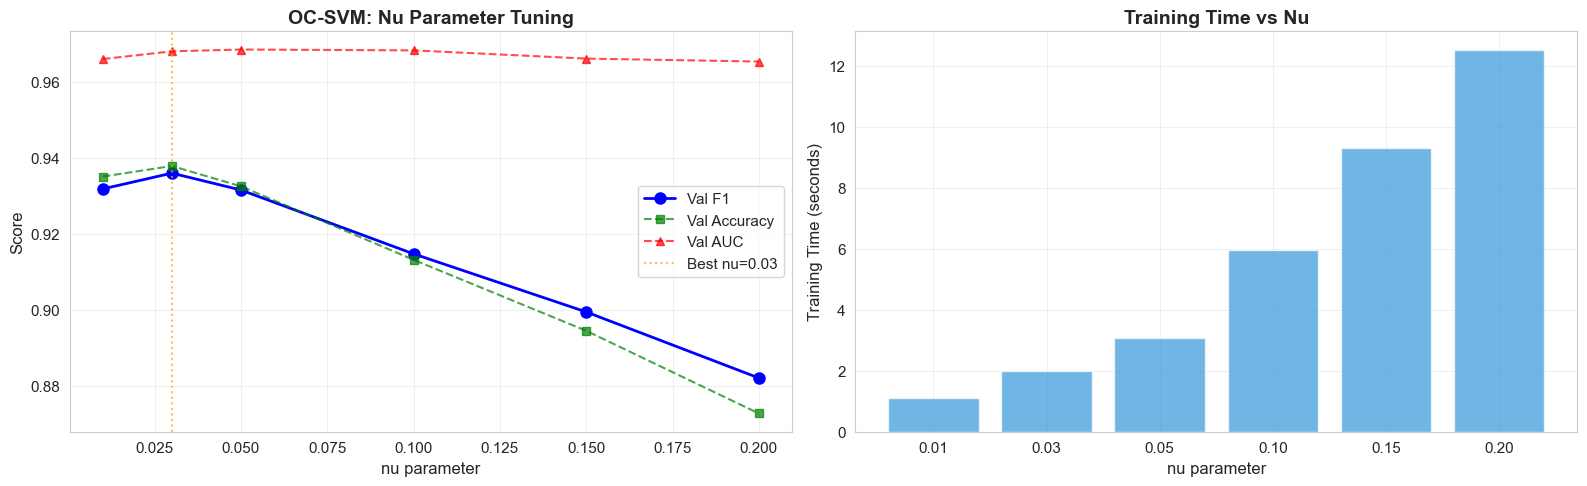

In [ ]:
# Tuning visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(ocsvm_tune_df['nu'], ocsvm_tune_df['val_f1'], 'b-o', linewidth=2,
             markersize=8, label='Val F1')
axes[0].plot(ocsvm_tune_df['nu'], ocsvm_tune_df['val_acc'], 'g--s',
             markersize=6, label='Val Accuracy', alpha=0.7)
axes[0].plot(ocsvm_tune_df['nu'], ocsvm_tune_df['val_auc'], 'r--^',
             markersize=6, label='Val AUC', alpha=0.7)
axes[0].axvline(best_nu, color='orange', linestyle=':', alpha=0.7,
                label=f'Best nu={best_nu}')
axes[0].set_xlabel('nu parameter')
axes[0].set_ylabel('Score')
axes[0].set_title('OC-SVM: Nu Parameter Tuning', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(len(ocsvm_tune_df)), ocsvm_tune_df['time_s'],
            color='#3498db', alpha=0.7)
axes[1].set_xticks(range(len(ocsvm_tune_df)))
axes[1].set_xticklabels([f'{nu:.2f}' for nu in ocsvm_tune_df['nu']])
axes[1].set_xlabel('nu parameter')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_title('Training Time vs Nu', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ocsvm_nu_tuning.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Final Model Training & Evaluation

Train the final OC-SVM with the best $\\nu$ value and evaluate on the held-out test set.

---

In [ ]:
print("=" * 60)
print(f"Training Final OC-SVM (nu={best_nu})")
print("=" * 60)

t0 = time.time()
ocsvm_final = OneClassSVM(kernel='rbf', gamma='scale', nu=best_nu)
ocsvm_final.fit(X_train_ocsvm)
train_time = time.time() - t0

ocsvm_test_scores = -ocsvm_final.decision_function(X_test_scaled)
ocsvm_test_preds = (ocsvm_final.predict(X_test_scaled) == -1).astype(int)

ocsvm_metrics = eval_model(y_test, ocsvm_test_preds, ocsvm_test_scores, 'One-Class SVM')

print(f"\nTraining time: {train_time:.1f}s")
print(f"Support vectors: {ocsvm_final.support_vectors_.shape[0]:,}")

Training Final OC-SVM (nu=0.03)

One-Class SVM — TEST RESULTS
              precision    recall  f1-score   support

      Normal       0.72      0.94      0.81      9711
     Anomaly       0.94      0.72      0.82     12833

    accuracy                           0.82     22544
   macro avg       0.83      0.83      0.82     22544
weighted avg       0.84      0.82      0.82     22544

ROC-AUC: 0.9040

Training time: 0.2s
Support vectors: 488


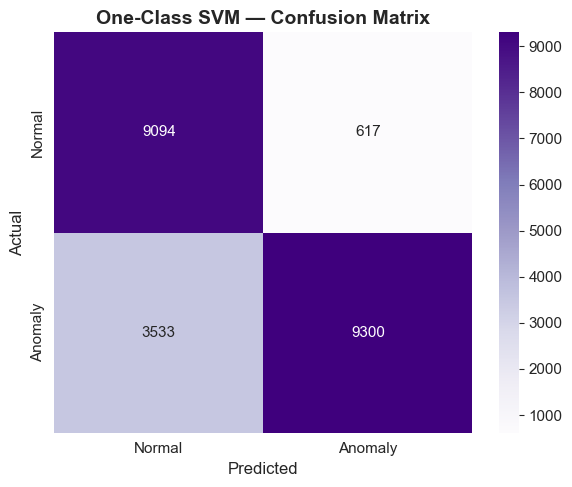

In [ ]:
# Confusion matrix and score distribution
plot_cm(y_test, ocsvm_test_preds, 'One-Class SVM — Confusion Matrix',
        os.path.join(RESULTS_DIR, 'ocsvm_cm.png'), 'Purples')

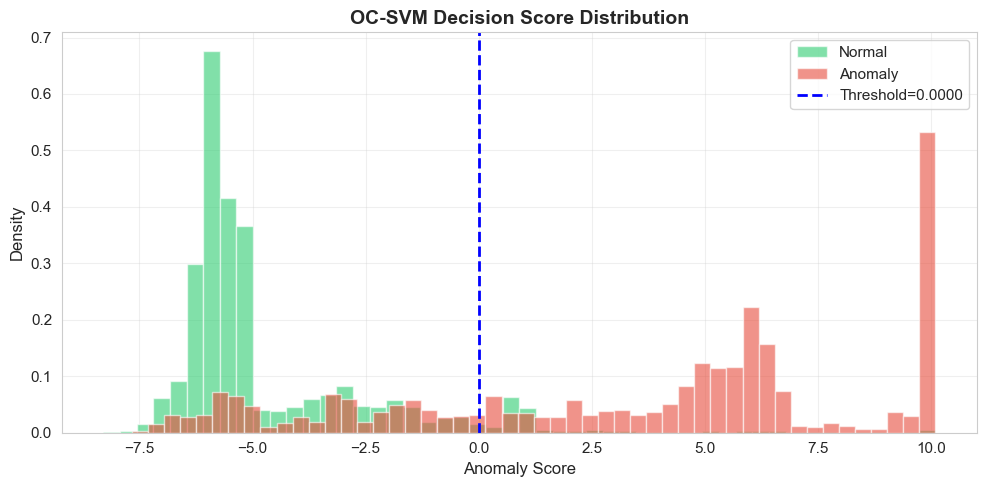

In [ ]:
plot_scores(ocsvm_test_scores, y_test, 0,
            'OC-SVM Decision Score Distribution',
            os.path.join(RESULTS_DIR, 'ocsvm_scores.png'))

## 5. Per-Attack-Family Analysis

We break down detection rates by attack family to understand model strengths and weaknesses.

---

OC-SVM: Per-Attack-Family Detection Rate
Family       Total   Detected     Rate   Missed
-----------------------------------------------------------------
DoS          7,458      6,058   81.2%    1,400
Probe        2,421      2,235   92.3%      186
R2L          2,887        965   33.4%    1,922
U2R             67         42   62.7%       25
-----------------------------------------------------------------
Normal(FP)   9,711        617    6.4%


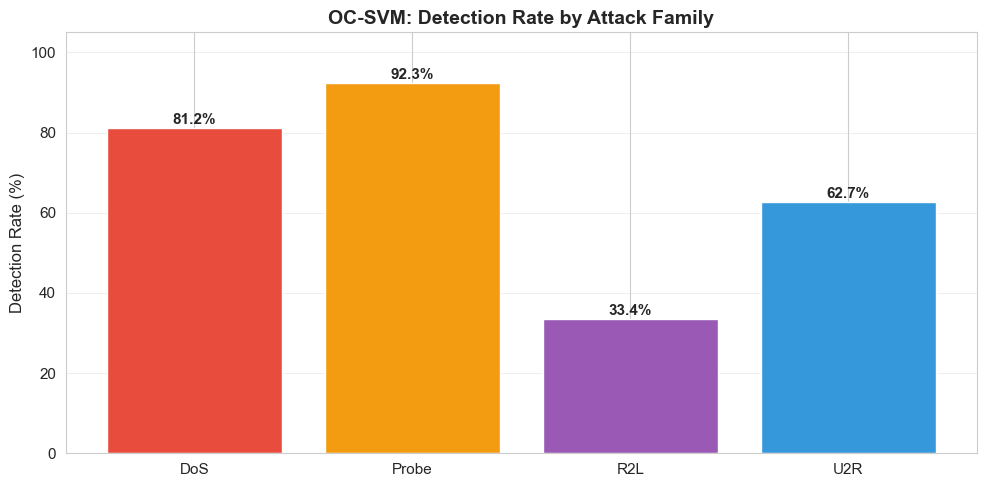

In [ ]:
print("OC-SVM: Per-Attack-Family Detection Rate")
print("=" * 65)
print(f"{'Family':<10} {'Total':>7} {'Detected':>10} {'Rate':>8} {'Missed':>8}")
print("-" * 65)

family_results = []
for fam in ['DoS', 'Probe', 'R2L', 'U2R']:
    mask = test_attack_cats == fam
    total = mask.sum()
    if total == 0:
        continue
    detected = ocsvm_test_preds[mask].sum()
    rate = detected / total
    print(f"{fam:<10} {total:>7,d} {detected:>10,d} {rate:>7.1%} {total-detected:>8,d}")
    family_results.append({'family': fam, 'total': total, 'detected': detected, 'rate': rate})

# False positive rate
nm = test_attack_cats == 'Normal'
fp = ocsvm_test_preds[nm].sum()
print("-" * 65)
print(f"{'Normal(FP)':<10} {nm.sum():>7,d} {fp:>10,d} {fp/nm.sum():>7.1%}")

# Bar chart
fam_df = pd.DataFrame(family_results)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c', '#f39c12', '#9b59b6', '#3498db']
bars = ax.bar(fam_df['family'], fam_df['rate'] * 100, color=colors)
ax.set_ylabel('Detection Rate (%)')
ax.set_title('OC-SVM: Detection Rate by Attack Family', fontweight='bold')
ax.set_ylim(0, 105)
for bar, rate in zip(bars, fam_df['rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{rate:.1%}', ha='center', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ocsvm_attack_detection.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Decision Boundary Visualisation (2D Projection)

We project the data to 2D using PCA and visualise the OC-SVM decision boundary.

---

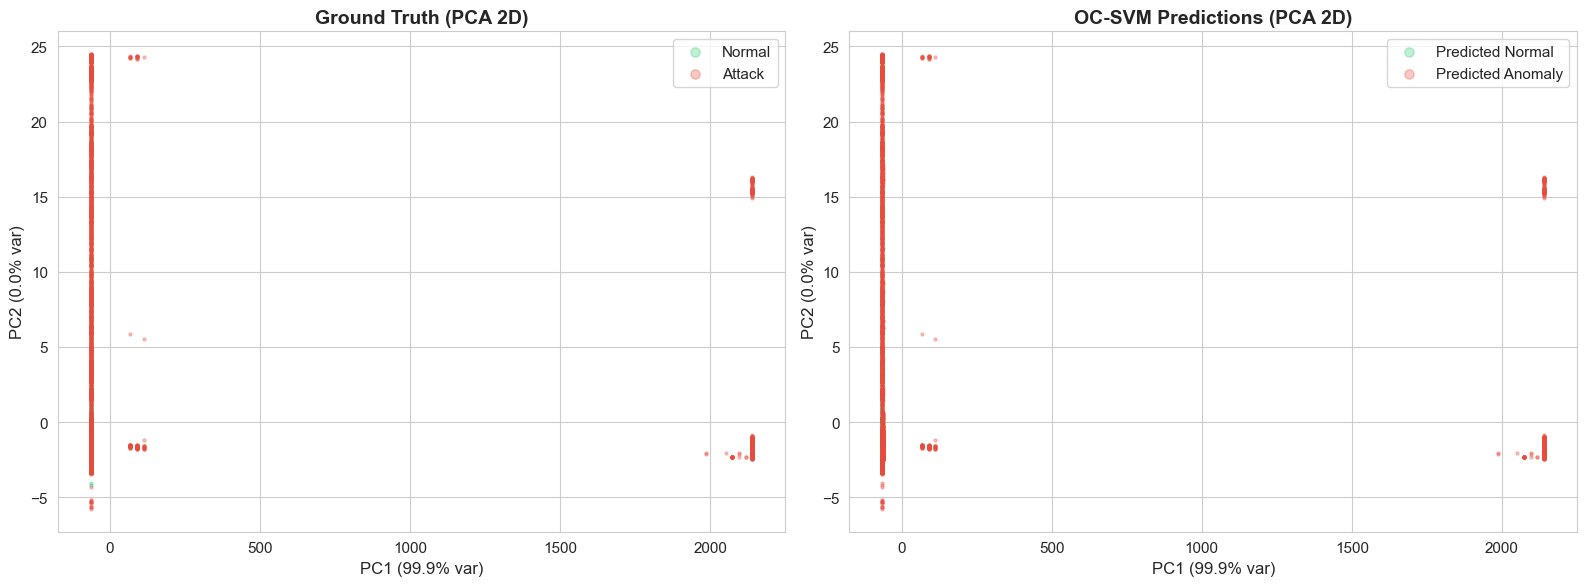

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
X_test_2d = pca.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ground truth
for label, color, name in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Attack')]:
    mask = y_test == label
    axes[0].scatter(X_test_2d[mask, 0], X_test_2d[mask, 1], c=color,
                    s=5, alpha=0.3, label=name)
axes[0].set_title('Ground Truth (PCA 2D)', fontweight='bold')
axes[0].legend(markerscale=3)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')

# OC-SVM predictions
for pred, color, name in [(0, '#2ecc71', 'Predicted Normal'), (1, '#e74c3c', 'Predicted Anomaly')]:
    mask = ocsvm_test_preds == pred
    axes[1].scatter(X_test_2d[mask, 0], X_test_2d[mask, 1], c=color,
                    s=5, alpha=0.3, label=name)
axes[1].set_title('OC-SVM Predictions (PCA 2D)', fontweight='bold')
axes[1].legend(markerscale=3)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ocsvm_2d_projection.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Results

---

In [ ]:
# Save model and metrics
with open(os.path.join(MODELS_DIR, 'ocsvm_model.pkl'), 'wb') as f:
    pickle.dump(ocsvm_final, f)

np.save(os.path.join(MODELS_DIR, 'ocsvm_test_scores.npy'), ocsvm_test_scores)
np.save(os.path.join(MODELS_DIR, 'ocsvm_test_preds.npy'), ocsvm_test_preds)

metrics_df = pd.DataFrame([ocsvm_metrics])
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'ocsvm_metrics.csv'), index=False)

print("Saved:")
print(f"  Model: {os.path.join(MODELS_DIR, 'ocsvm_model.pkl')}")
print(f"  Scores: {os.path.join(MODELS_DIR, 'ocsvm_test_scores.npy')}")
print(f"  Metrics: {os.path.join(RESULTS_DIR, 'ocsvm_metrics.csv')}")
print(f"\nOC-SVM training complete.")

Saved:
  Model: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../models/ocsvm_model.pkl
  Scores: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../models/ocsvm_test_scores.npy
  Metrics: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../results/ocsvm_metrics.csv

OC-SVM training complete.
